# Lab 01 — Solution

Goals:
1. Implement the first reinforcement-learning agent (a state-conditioned Multi-Armed Bandit).
2. Study the exploration/exploitation dilemma via `epsilon`-greedy.
3. Plot average reward vs. iterations to compare the two agents.

Environment: GridWorld with special teleport cells that yield a reward when entered.

## 1.1 Gridworld Simulator

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
class environment:
    def __init__(self, grid_height, grid_width):
        self.height = grid_height
        self.width = grid_width
        self.start = []
        self.end = []
        self.reward = []
        self.map = np.array([i for i in range(grid_height * grid_width)])
        self.action_space = [0, 1, 2, 3]   # UP, DOWN, LEFT, RIGHT

    def get_Map(self):
        print(self.map.reshape([self.width, self.height]))

    def get_NumState(self):
        return self.height * self.width

    def map_Designate(self, start_cell, end_cell, reward):
        self.start.append(start_cell)
        self.end.append(end_cell)
        self.reward.append(reward)

    def get_Observation(self, location, action):
        if action == -1:
            return None, self.action_space, None

        if location in self.start:
            idx = self.start.index(location)
            return self.end[idx], self.action_space, self.reward[idx]

        reward = 0
        new_location = location

        if action == 0:    # UP
            if location - self.width >= 0:
                new_location = location - self.width
        elif action == 1:  # DOWN
            if location + self.width <= self.height * self.width - 1:
                new_location = location + self.width
        elif action == 2:  # LEFT
            if location % self.width != 0:
                new_location = location - 1
        elif action == 3:  # RIGHT
            if (location + 1) % self.width != 0:
                new_location = location + 1

        return new_location, self.action_space, reward

### Build the map

In [3]:
Envir = environment(8, 8)
Envir.get_Map()

# negative cells (traps): -15
for s in [17, 18, 19, 21, 25, 33, 41, 42, 43, 46, 47]:
    Envir.map_Designate(s, 56, -15)

# positive cells
Envir.map_Designate(15, 56, +15)
Envir.map_Designate(1, 10, +5)
Envir.map_Designate(26, 56, +20)

for i in range(len(Envir.start)):
    print(f'i = {i}|Start at {Envir.start[i]} results at {Envir.end[i]} get Reward: {Envir.reward[i]}')

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]
i = 0|Start at 17 results at 56 get Reward: -15
i = 1|Start at 18 results at 56 get Reward: -15
i = 2|Start at 19 results at 56 get Reward: -15
i = 3|Start at 21 results at 56 get Reward: -15
i = 4|Start at 25 results at 56 get Reward: -15
i = 5|Start at 33 results at 56 get Reward: -15
i = 6|Start at 41 results at 56 get Reward: -15
i = 7|Start at 42 results at 56 get Reward: -15
i = 8|Start at 43 results at 56 get Reward: -15
i = 9|Start at 46 results at 56 get Reward: -15
i = 10|Start at 47 results at 56 get Reward: -15
i = 11|Start at 15 results at 56 get Reward: 15
i = 12|Start at 1 results at 10 get Reward: 5
i = 13|Start at 26 results at 56 get Reward: 20


## 1.2 Agent — Multi-Armed Bandit (greedy, no exploration)

We keep a Q-table `Q[state][action]` of running averages of immediate rewards.
At each step we pick the action with the highest Q-value at the current state
(ties broken at random).  No exploration is added yet.

In [4]:
class MAB_agent:
    def __init__(self, envir, init_location):
        self.envir = envir
        self.reward_trace = []
        self.location_now = init_location

        num_states = envir.get_NumState()
        num_actions = len(envir.action_space)
        self.Q_table = np.zeros((num_states, num_actions), dtype=float)
        self.count = np.zeros((num_states, num_actions), dtype=int)

        self.prev_state = None
        self.prev_action = None

    def get_TotalReward(self):
        return np.sum(self.reward_trace)

    def _update(self, state, action, reward):
        self.count[state][action] += 1
        n = self.count[state][action]
        self.Q_table[state][action] += (reward - self.Q_table[state][action]) / n

    def _greedy(self, state, action_space):
        q = self.Q_table[state]
        max_q = q.max()
        best = [a for a in action_space if q[a] == max_q]
        return int(np.random.choice(best))

    def getAction(self, observation):
        location_now, action_space, pre_reward = observation

        if location_now is not None:
            self.location_now = location_now

        if pre_reward is not None:
            self.reward_trace.append(pre_reward)
            if self.prev_state is not None and self.prev_action is not None:
                self._update(self.prev_state, self.prev_action, pre_reward)

        action = self._greedy(self.location_now, action_space)
        self.prev_state = self.location_now
        self.prev_action = action

        assert action in action_space, 'INVALID action taken'
        return action

## 1.3 Exploration via $\epsilon$-greedy

With probability $\epsilon$ pick a uniformly random action, otherwise pick the greedy one.

In [5]:
class MABe_agent(MAB_agent):
    def __init__(self, envir, init_location, epsilon=0.1):
        super().__init__(envir, init_location)
        self.epsilon = epsilon

    def _epsilon_greedy(self, state, action_space):
        if np.random.rand() <= self.epsilon:
            return int(np.random.choice(action_space))
        return self._greedy(state, action_space)

    def getAction(self, observation):
        location_now, action_space, pre_reward = observation

        if location_now is not None:
            self.location_now = location_now

        if pre_reward is not None:
            self.reward_trace.append(pre_reward)
            if self.prev_state is not None and self.prev_action is not None:
                self._update(self.prev_state, self.prev_action, pre_reward)

        action = self._epsilon_greedy(self.location_now, action_space)
        self.prev_state = self.location_now
        self.prev_action = action

        assert action in action_space, 'INVALID action taken'
        return action

## 1.4 Simulation helper

In [6]:
def run_simulation(agent, envir, num_iter, log_freq, init_location=0, label=''):
    data_plot = []
    chosen_action = -1
    for i in range(num_iter):
        if i == 0:
            env_observation = (init_location, envir.action_space, None)
        else:
            env_observation = envir.get_Observation(
                location=agent.location_now, action=chosen_action)
        chosen_action = agent.getAction(observation=env_observation)

        if (i + 1) % log_freq == 0:
            aver = np.mean(agent.reward_trace) if agent.reward_trace else 0.0
            data_plot.append(aver)
            print(f'{label} iter: {i + 1}\t Total reward: {agent.get_TotalReward():.2f}\t Average: {aver:.4f}')
    return data_plot

In [7]:
# Greedy MAB (no exploration)
np.random.seed(42)
init_location = 0
dummyAgent = MAB_agent(envir=Envir, init_location=init_location)
Data_plot1 = run_simulation(dummyAgent, Envir, num_iter=1000, log_freq=100,
                            init_location=init_location, label='[MAB ]')

[MAB ] iter: 100	 Total reward: -60.00	 Average: -0.6061
[MAB ] iter: 200	 Total reward: -120.00	 Average: -0.6030
[MAB ] iter: 300	 Total reward: -195.00	 Average: -0.6522
[MAB ] iter: 400	 Total reward: -300.00	 Average: -0.7519
[MAB ] iter: 500	 Total reward: -420.00	 Average: -0.8417
[MAB ] iter: 600	 Total reward: -525.00	 Average: -0.8765
[MAB ] iter: 700	 Total reward: -585.00	 Average: -0.8369
[MAB ] iter: 800	 Total reward: -690.00	 Average: -0.8636
[MAB ] iter: 900	 Total reward: -855.00	 Average: -0.9511
[MAB ] iter: 1000	 Total reward: -945.00	 Average: -0.9459


In [8]:
# Epsilon-greedy MAB
np.random.seed(42)
eGreedyAgent = MABe_agent(envir=Envir, init_location=init_location, epsilon=0.1)
Data_plot2 = run_simulation(eGreedyAgent, Envir, num_iter=1000, log_freq=100,
                            init_location=init_location, label='[MABe]')

[MABe] iter: 100	 Total reward: -145.00	 Average: -1.4646
[MABe] iter: 200	 Total reward: -250.00	 Average: -1.2563
[MABe] iter: 300	 Total reward: -385.00	 Average: -1.2876
[MABe] iter: 400	 Total reward: -440.00	 Average: -1.1028
[MABe] iter: 500	 Total reward: -515.00	 Average: -1.0321
[MABe] iter: 600	 Total reward: -590.00	 Average: -0.9850
[MABe] iter: 700	 Total reward: -665.00	 Average: -0.9514
[MABe] iter: 800	 Total reward: -755.00	 Average: -0.9449
[MABe] iter: 900	 Total reward: -875.00	 Average: -0.9733
[MABe] iter: 1000	 Total reward: -995.00	 Average: -0.9960


## 1.5 Plot

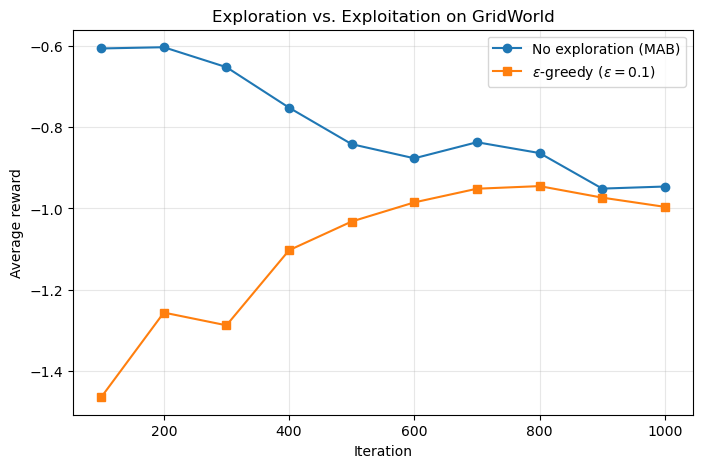

In [9]:
fig = plt.figure(figsize=(8, 5))
x = np.arange(1, len(Data_plot1) + 1) * 100
plt.plot(x, Data_plot1, marker='o', label='No exploration (MAB)')
plt.plot(x, Data_plot2, marker='s', label='$\\epsilon$-greedy ($\\epsilon=0.1$)')
plt.xlabel('Iteration')
plt.ylabel('Average reward')
plt.title('Exploration vs. Exploitation on GridWorld')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Discussion

* The greedy MAB agent quickly locks onto whatever action looked best on the very first updates, so it tends to get stuck in a sub-optimal corner of the map.
* The $\epsilon$-greedy agent occasionally tries random actions, discovers higher-reward teleport cells (e.g. state 26 → +20), and ends up with a higher average reward in the long run.
* This is the classic exploration/exploitation trade-off: a little exploration costs a little immediate reward but pays off in the long run.